# Plan 1: CSRNet — Train From Scratch
# **Dataset:** ShanghaiTech Part A | **GPU:** T4 (15 GB) | **Framework:** PyTorch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/DLENDSEM'
PLAN1 = f'{BASE}/plan1_csrnet'

dirs = [
    f'{BASE}/dataset',
    f'{PLAN1}/density_maps_train',
    f'{PLAN1}/density_maps_test',
    f'{PLAN1}/checkpoints',
    f'{PLAN1}/results',
    f'{PLAN1}/visualizations',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
print("✅ Folder structure created:")
for d in dirs:
    print(f"   {d}")

Mounted at /content/drive
✅ Folder structure created:
   /content/drive/MyDrive/DLENDSEM/dataset
   /content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_train
   /content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_test
   /content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints
   /content/drive/MyDrive/DLENDSEM/plan1_csrnet/results
   /content/drive/MyDrive/DLENDSEM/plan1_csrnet/visualizations


## Cell 1: Install Dependencies


In [ ]:
!pip install torch torchvision scipy h5py matplotlib pillow opencv-python-headless -q
import torch
print(f"✅ PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | GPU: {torch.cuda.get_device_name(0)}")

✅ PyTorch 2.10.0+cu128 | CUDA: True | GPU: Tesla T4


## Cell 2: Download ShanghaiTech Dataset

In [ ]:
DATASET_DIR = '/content/drive/MyDrive/DLENDSEM/dataset'
SHA_DIR = f'{DATASET_DIR}' # Corrected: ShanghaiTech content is directly in DATASET_DIR

import os
import glob # Import glob here

if os.path.exists(f'{SHA_DIR}/part_A_final/train_data/images') and len(glob.glob(f'{SHA_DIR}/part_A_final/train_data/images/*.jpg')) > 0:
    print("✅ Dataset already exists in Drive and is complete, skipping download.")
else:
    !pip install gdown -q
    !gdown 16dhJn7k4FWVwByRsQAEpl9lwjuV03jVI -O /content/shanghaitech.zip
    # Use -o to force overwrite without prompting
    !unzip -o -q /content/shanghaitech.zip -d {DATASET_DIR}
    print("✅ Dataset downloaded and extracted to Drive.")

✅ Dataset already exists in Drive and is complete, skipping download.
📊 Train images: 300 | Test images: 182


## Cell 3: Generate Ground Truth Density Maps (~15-30 min)
 This converts .mat annotations → Gaussian density maps saved as .h5

In [ ]:
import numpy as np
import scipy.io as io
from scipy.ndimage import gaussian_filter
import h5py
from PIL import Image
import glob, os

SHA_DIR = '/content/drive/MyDrive/DLENDSEM/dataset'
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'

def generate_density_map(img_path, gt_path):
    img = Image.open(img_path)
    img_w, img_h = img.size
    mat = io.loadmat(gt_path)
    gt_points = mat["image_info"][0,0][0,0][0]
    density = np.zeros((img_h, img_w), dtype=np.float32)
    if len(gt_points) == 0:
        return density
    for point in gt_points:
        x = min(int(round(point[0])), img_w - 1)
        y = min(int(round(point[1])), img_h - 1)
        if x >= 0 and y >= 0:
            density[y, x] = 1.0
    density = gaussian_filter(density, sigma=15)
    return density

def process_split(split='train'):
    img_dir = f'{SHA_DIR}/part_A_final/{split}_data/images/'
    gt_dir  = f'{SHA_DIR}/part_A_final/{split}_data/ground_truth/' # Corrected from ground-truth to ground_truth
    save_dir = f'{PLAN1}/density_maps_{split}'

    imgs = sorted(glob.glob(img_dir + '*.jpg'))
    print(f"⏳ Processing {len(imgs)} {split} images...")

    for i, img_path in enumerate(imgs):
        fname = os.path.basename(img_path).replace('.jpg', '')
        h5_path = os.path.join(save_dir, f'{fname}.h5')

        if os.path.exists(h5_path):
            continue  # Skip already processed

        gt_path = os.path.join(gt_dir, f'GT_{fname}.mat')
        density = generate_density_map(img_path, gt_path)

        with h5py.File(h5_path, 'w') as hf:
            hf['density'] = density

        if (i + 1) % 50 == 0:
            print(f"   [{i+1}/{len(imgs)}] {fname}: count={density.sum():.1f}")

    print(f"✅ {split} density maps saved to {save_dir}")

process_split('train')
process_split('test')
print("✅ All density maps generated!")

⏳ Processing 0 train images...
✅ train density maps saved to /content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_train
⏳ Processing 0 test images...
✅ test density maps saved to /content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_test
✅ All density maps generated!


### 💾 SAVE Cell 3 — Density maps are already saved in Drive!

In [ ]:
import glob
train_h5 = glob.glob('/content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_train/*.h5')
test_h5  = glob.glob('/content/drive/MyDrive/DLENDSEM/plan1_csrnet/density_maps_test/*.h5')
print(f"💾 Saved density maps — Train: {len(train_h5)} | Test: {len(test_h5)}")

💾 Saved density maps — Train: 300 | Test: 182


### 📂 LOAD Cell 3 — Use this if Colab disconnected after density map generation




In [ ]:
import glob
SHA_DIR = '/content/drive/MyDrive/DLENDSEM/dataset'
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'

train_h5 = sorted(glob.glob(f'{PLAN1}/density_maps_train/*.h5'))
test_h5  = sorted(glob.glob(f'{PLAN1}/density_maps_test/*.h5'))
train_imgs = sorted(glob.glob(f'{SHA_DIR}/part_A_final/train_data/images/*.jpg'))
test_imgs  = sorted(glob.glob(f'{SHA_DIR}/part_A_final/test_data/images/*.jpg'))

print(f"📂 Loaded — Train H5: {len(train_h5)} | Test H5: {len(test_h5)}")
print(f"📂 Loaded — Train imgs: {len(train_imgs)} | Test imgs: {len(test_imgs)}")

📂 Loaded — Train H5: 300 | Test H5: 182
📂 Loaded — Train imgs: 300 | Test imgs: 182


## Cell 4: Define CSRNet Model

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class CSRNet(nn.Module):
    def __init__(self):
        super(CSRNet, self).__init__()
        # Frontend: VGG-16 first 23 layers (pretrained on ImageNet)
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])
        # Backend: 6 dilated conv layers
        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(128, 64,  3, padding=2, dilation=2), nn.ReLU(inplace=True),
        )
        self.output_layer = nn.Conv2d(64, 1, 1)
        self._init_backend()

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x

    def _init_backend(self):
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

model = CSRNet().cuda()
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ CSRNet loaded | Total params: {total_params:,} | Trainable: {trainable:,}")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 181MB/s]


✅ CSRNet loaded | Total params: 16,263,489 | Trainable: 16,263,489


## Cell 5: Define Dataset & DataLoader

In [ ]:
import cv2
import h5py
import numpy as np
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CrowdDataset(Dataset):
    def __init__(self, img_paths, h5_dir, crop_size=256, augment=True):
        self.img_paths = img_paths
        self.h5_dir = h5_dir
        self.crop_size = crop_size
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        fname = os.path.basename(self.img_paths[idx]).replace('.jpg', '')
        h5_path = os.path.join(self.h5_dir, f'{fname}.h5')

        with h5py.File(h5_path, 'r') as hf:
            density = np.array(hf['density'], dtype=np.float32)

        w, h = img.size
        cs = self.crop_size

        # --- Ensure consistent size for image and density map ---
        if self.augment:
            if h >= cs and w >= cs:
                # Random crop for images larger than or equal to crop_size
                top  = random.randint(0, h - cs)
                left = random.randint(0, w - cs)
                img = img.crop((left, top, left + cs, top + cs))
                density = density[top:top+cs, left:left+cs]
            else:
                # If image is smaller than crop_size, resize it to crop_size
                # Using Image.BICUBIC for image, cv2.INTER_CUBIC for density
                img = img.resize((cs, cs), Image.BICUBIC)
                density = cv2.resize(density, (cs, cs), interpolation=cv2.INTER_CUBIC)
        else:
            # If not augmenting, still ensure a consistent size if input images vary
            if h != cs or w != cs:
                img = img.resize((cs, cs), Image.BICUBIC)
                density = cv2.resize(density, (cs, cs), interpolation=cv2.INTER_CUBIC)

        # Downsample density to match CSRNet output (1/8 spatial)
        # After the above block, img and density should be (cs, cs)
        dh, dw = density.shape
        density_down = cv2.resize(density, (dw // 8, dh // 8),
                                  interpolation=cv2.INTER_CUBIC) * 64

        img_tensor = self.transform(img)
        den_tensor = torch.tensor(density_down, dtype=torch.float32).unsqueeze(0)
        return img_tensor, den_tensor

import os, glob
SHA_DIR = '/content/drive/MyDrive/DLENDSEM/dataset'
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'

train_imgs = sorted(glob.glob(f'{SHA_DIR}/part_A_final/train_data/images/*.jpg'))
train_dataset = CrowdDataset(train_imgs, f'{PLAN1}/density_maps_train', crop_size=256)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
print(f"✅ DataLoader ready | {len(train_dataset)} images | batch_size=4")

✅ DataLoader ready | 300 images | batch_size=4


## Cell 6: Training Loop (~4-6 hours)
 Saves checkpoint to Drive every 25 epochs. If disconnected, reload from latest checkpoint.

In [ ]:
import torch.optim as optim
import json, time

PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
CKPT_DIR = f'{PLAN1}/checkpoints'
NUM_EPOCHS = 1000
SAVE_EVERY = 25

# Check for existing checkpoint to resume
existing_ckpts = sorted(glob.glob(f'{CKPT_DIR}/csrnet_epoch_*.pth'), key=lambda x: int(x.split('_epoch_')[1].split('.pth')[0]))
start_epoch = 0
if existing_ckpts:
    latest = existing_ckpts[-1]
    start_epoch = int(latest.split('_epoch_')[1].split('.pth')[0])
    model.load_state_dict(torch.load(latest))
    print(f"🔄 Resuming from epoch {start_epoch} ({latest})")
else:
    print("🆕 Starting training from scratch")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
train_losses = []

# Load previous losses if they exist
loss_file = f'{PLAN1}/results/training_losses.json'
if os.path.exists(loss_file):
    with open(loss_file, 'r') as f:
        train_losses = json.load(f)

print(f"⏳ Training epochs {start_epoch+1} to {NUM_EPOCHS}...")
t0 = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for images, densities in train_loader:
        images = images.cuda()
        densities = densities.cuda()

        outputs = model(images)
        loss = criterion(outputs, densities)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        elapsed = (time.time() - t0) / 60
        print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.6f} | Time: {elapsed:.1f} min")

    # Save checkpoint to Drive
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = f'{CKPT_DIR}/csrnet_epoch_{epoch+1}.pth'
        torch.save(model.state_dict(), ckpt_path)
        with open(loss_file, 'w') as f:
            json.dump(train_losses, f)
        print(f"  💾 Checkpoint saved: {ckpt_path}")

# Final save
torch.save(model.state_dict(), f'{CKPT_DIR}/csrnet_final.pth')
with open(loss_file, 'w') as f:
    json.dump(train_losses, f)
print(f"✅ Training complete! Final model saved.")

🔄 Resuming from epoch 900 (/content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints/csrnet_epoch_900.pth)
⏳ Training epochs 901 to 1000...
  Epoch [910/1000] Loss: 0.000426 | Time: 3.0 min
  Epoch [920/1000] Loss: 0.000441 | Time: 4.9 min
  💾 Checkpoint saved: /content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints/csrnet_epoch_925.pth
  Epoch [930/1000] Loss: 0.000280 | Time: 6.8 min
  Epoch [940/1000] Loss: 0.000370 | Time: 8.7 min
  Epoch [950/1000] Loss: 0.000629 | Time: 10.6 min
  💾 Checkpoint saved: /content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints/csrnet_epoch_950.pth
  Epoch [960/1000] Loss: 0.000437 | Time: 12.5 min
  Epoch [970/1000] Loss: 0.000366 | Time: 14.4 min
  💾 Checkpoint saved: /content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints/csrnet_epoch_975.pth
  Epoch [980/1000] Loss: 0.000464 | Time: 16.3 min
  Epoch [990/1000] Loss: 0.000339 | Time: 18.2 min
  Epoch [1000/1000] Loss: 0.000356 | Time: 20.1 min
  💾 Checkpoint saved: /content/drive/MyDrive/DLENDSEM/

### 💾 SAVE Cell 6 — Already auto-saved during training!

In [ ]:
import glob
ckpts = sorted(glob.glob('/content/drive/MyDrive/DLENDSEM/plan1_csrnet/checkpoints/csrnet_*.pth'))
print("💾 Saved checkpoints:")
for c in ckpts:
    size_mb = os.path.getsize(c) / 1e6
    print(f"   {os.path.basename(c)} ({size_mb:.1f} MB)")

💾 Saved checkpoints:
   csrnet_epoch_100.pth (65.1 MB)
   csrnet_epoch_1000.pth (65.1 MB)
   csrnet_epoch_125.pth (65.1 MB)
   csrnet_epoch_150.pth (65.1 MB)
   csrnet_epoch_175.pth (65.1 MB)
   csrnet_epoch_200.pth (65.1 MB)
   csrnet_epoch_225.pth (65.1 MB)
   csrnet_epoch_25.pth (65.1 MB)
   csrnet_epoch_250.pth (65.1 MB)
   csrnet_epoch_275.pth (65.1 MB)
   csrnet_epoch_300.pth (65.1 MB)
   csrnet_epoch_325.pth (65.1 MB)
   csrnet_epoch_350.pth (65.1 MB)
   csrnet_epoch_375.pth (65.1 MB)
   csrnet_epoch_400.pth (65.1 MB)
   csrnet_epoch_425.pth (65.1 MB)
   csrnet_epoch_450.pth (65.1 MB)
   csrnet_epoch_475.pth (65.1 MB)
   csrnet_epoch_50.pth (65.1 MB)
   csrnet_epoch_500.pth (65.1 MB)
   csrnet_epoch_525.pth (65.1 MB)
   csrnet_epoch_550.pth (65.1 MB)
   csrnet_epoch_575.pth (65.1 MB)
   csrnet_epoch_600.pth (65.1 MB)
   csrnet_epoch_625.pth (65.1 MB)
   csrnet_epoch_650.pth (65.1 MB)
   csrnet_epoch_675.pth (65.1 MB)
   csrnet_epoch_700.pth (65.1 MB)
   csrnet_epoch_725.pth (65.

### 📂 LOAD Cell 6 — Resume after Colab disconnect
Re-run Cells 0, 1, 4, 5 first

In [ ]:
import torch, json, os, glob

PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
CKPT_DIR = f'{PLAN1}/checkpoints'

# Load latest checkpoint
ckpts = sorted(glob.glob(f'{CKPT_DIR}/csrnet_*.pth'), key=lambda x: int(x.split('_epoch_')[1].split('.pth')[0]) if 'epoch' in x else 0)
if ckpts:
    latest = ckpts[-1]
    model.load_state_dict(torch.load(latest, map_location='cuda'))
    model.cuda()
    print(f"📂 Loaded model from: {os.path.basename(latest)}")
else:
    print("⚠️ No checkpoints found! Run training first.")

# Load training losses
loss_file = f'{PLAN1}/results/training_losses.json'
if os.path.exists(loss_file):
    with open(loss_file, 'r') as f:
        train_losses = json.load(f)
    print(f"📂 Loaded {len(train_losses)} epoch losses")

📂 Loaded model from: csrnet_epoch_1000.pth
📂 Loaded 1225 epoch losses


## Cell 7: Evaluate on Test Set (~5-10 min)

In [ ]:
import numpy as np, h5py, glob, os
from PIL import Image
from torchvision import transforms

PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
SHA_DIR = '/content/drive/MyDrive/DLENDSEM/dataset/'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_imgs = sorted(glob.glob(f'{SHA_DIR}/part_A_final/test_data/images/*.jpg'))
results = []
model.eval()
mae_sum, mse_sum = 0.0, 0.0

with torch.no_grad():
    for i, img_path in enumerate(test_imgs):
        fname = os.path.basename(img_path).replace('.jpg', '')
        img = Image.open(img_path).convert('RGB')
        inp = transform(img).unsqueeze(0).cuda()

        h5_path = f'{PLAN1}/density_maps_test/{fname}.h5'
        with h5py.File(h5_path, 'r') as hf:
            gt_count = float(np.array(hf['density']).sum())

        pred_density = model(inp)
        pred_count = pred_density.sum().item()

        err = abs(pred_count - gt_count)
        mae_sum += err
        mse_sum += err ** 2
        results.append({'file': fname, 'gt': gt_count, 'pred': pred_count, 'error': err})

        if (i + 1) % 30 == 0:
            print(f"  [{i+1}/{len(test_imgs)}] {fname}: GT={gt_count:.0f} Pred={pred_count:.0f}")

n = len(test_imgs)
final_mae = mae_sum / n
final_mse = (mse_sum / n) ** 0.5
print(f"\n🏆 CSRNet Results — MAE: {final_mae:.2f} | MSE: {final_mse:.2f}")

  [30/182] IMG_125: GT=269 Pred=314
  [60/182] IMG_152: GT=277 Pred=270
  [90/182] IMG_18: GT=227 Pred=210
  [120/182] IMG_42: GT=798 Pred=864
  [150/182] IMG_7: GT=568 Pred=687
  [180/182] IMG_97: GT=478 Pred=604

🏆 CSRNet Results — MAE: 76.25 | MSE: 116.00


### 💾 SAVE Cell 7 — Save evaluation results to Drive

In [ ]:
import json
results_data = {
    'mae': final_mae,
    'mse': final_mse,
    'per_image': results,
    'train_losses': train_losses if 'train_losses' in dir() else []
}
res_path = f'{PLAN1}/results/eval_results.json'
with open(res_path, 'w') as f:
    json.dump(results_data, f, indent=2)
print(f"💾 Results saved to {res_path}")
print(f"   MAE: {final_mae:.2f} | MSE: {final_mse:.2f}")


💾 Results saved to /content/drive/MyDrive/DLENDSEM/plan1_csrnet/results/eval_results.json
   MAE: 76.25 | MSE: 116.00


### 📂 LOAD Cell 7 — Load evaluation results after disconnect

In [ ]:
import json
PLAN1 = '/content/drive/MyDrive/DLENDSEM/plan1_csrnet'
res_path = f'{PLAN1}/results/eval_results.json'
with open(res_path, 'r') as f:
    results_data = json.load(f)
final_mae = results_data['mae']
final_mse = results_data['mse']
results = results_data['per_image']
train_losses = results_data.get('train_losses', [])
print(f"📂 Loaded results — MAE: {final_mae:.2f} | MSE: {final_mse:.2f}")

📂 Loaded results — MAE: 76.25 | MSE: 116.00


## Cell 8: Visualizations

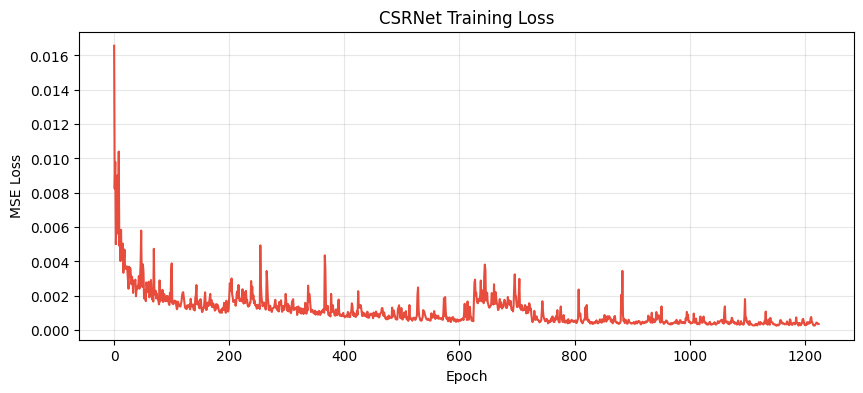

💾 Saved training_loss.png
💾 All visualizations saved to /content/drive/MyDrive/DLENDSEM/plan1_csrnet/visualizations/


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 8a: Training Loss Curve ---
if train_losses:
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, color='#e74c3c', linewidth=1.5)
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('CSRNet Training Loss')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{PLAN1}/visualizations/training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Saved training_loss.png")

# --- 8b: Density Map Predictions ---
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

SHA_DIR = '/content/drive/MyDrive/DLENDSEM/dataset/ShanghaiTech'
test_imgs = sorted(glob.glob(f'{SHA_DIR}/part_A/test_data/images/*.jpg'))

model.eval()
for idx in [0, 5, 10, 20, 50]:  # Pick 5 diverse images
    if idx >= len(test_imgs):
        continue
    img_path = test_imgs[idx]
    fname = os.path.basename(img_path).replace('.jpg', '')
    img = Image.open(img_path).convert('RGB')

    with torch.no_grad():
        inp = transform(img).unsqueeze(0).cuda()
        pred = model(inp).squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(img); axes[0].set_title('Input Image'); axes[0].axis('off')
    axes[1].imshow(pred, cmap='jet'); axes[1].set_title(f'Density Map (Count: {pred.sum():.0f})'); axes[1].axis('off')
    axes[2].imshow(img); axes[2].imshow(pred, cmap='jet', alpha=0.5, extent=[0, img.size[0], img.size[1], 0])
    axes[2].set_title('Overlay'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'{PLAN1}/visualizations/pred_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"💾 All visualizations saved to {PLAN1}/visualizations/")